# Elo Merchant Category Recommendation

<img src='https://instabill.com/wp-content/uploads/2015/09/merchant-category-code-instabill.jpg'>

Bu çalışmada `Elo Merchant Category Recommendation` yarışması için veri yapısı incelenmiş, zengin feature engineering uygulanmış ve boosting tabanlı modeller karşılaştırılarak en iyi `RMSE` sonucu elde edilmeye çalışılmıştır.

## Akış

1. Kütüphaneleri yükleme
2. Drive bağlama ve zip açma
3. Veri dosyalarını tanımlama
4. Ana tabloları inceleme
5. Hedef değişken analizi
6. Transaction analizi
7. Gelişmiş feature engineering
8. Boosting modelleri
9. RMSE değerlendirmesi
10. Sonuç

## 1. Kütüphaneleri Yükleme

In [1]:
# Bu bölümde gerekli veri analizi, görselleştirme ve baseline model kütüphanelerini içe aktarıyoruz.


In [2]:
!pip install lightgbm xgboost catboost -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [3]:
from google.colab import drive
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 2. Drive Bağlama ve Zip Açma

In [4]:
# Bu bölümde Google Drive içindeki yarışma zip dosyasını Colab çalışma alanına açıyoruz.


In [5]:
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/elo-merchant-category-recommendation.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]

Mounted at /content/drive


['.config',
 'sample_submission.csv',
 'train.csv',
 'Data Dictionary.xlsx',
 'historical_transactions.csv',
 'merchants.csv',
 'drive',
 'test.csv',
 'new_merchant_transactions.csv',
 'Data_Dictionary.xlsx',
 'sample_data']

## 3. Veri Dosyalarını Tanımlama

In [6]:
# Bu bölümde açılan dosyaların yollarını tanımlıyoruz.


In [7]:
search_roots = ['/content', '/content/drive/MyDrive/Colab Data Dosyaları']
train_path = None

for root in search_roots:
    for current_root, dirs, files in os.walk(root):
        if 'train.csv' in files and 'test.csv' in files:
            train_path = os.path.join(current_root, 'train.csv')
            test_path = os.path.join(current_root, 'test.csv')
            historical_path = os.path.join(current_root, 'historical_transactions.csv')
            new_merchant_path = os.path.join(current_root, 'new_merchant_transactions.csv')
            merchants_path = os.path.join(current_root, 'merchants.csv')
            data_path = current_root
            break
    if train_path is not None:
        break

if train_path is None:
    raise FileNotFoundError('train.csv ve test.csv ayni klasorde bulunamadi. Zip acma hucresini ve klasor yapisini kontrol et.')

print('Veri klasoru:', data_path)
print('Train dosyasi:', train_path)
print('Test dosyasi:', test_path)


Veri klasoru: /content
Train dosyasi: /content/train.csv
Test dosyasi: /content/test.csv


## 4. Ana Tabloları İnceleme

In [8]:
# Bu bölümde `train` ve `test` tablolarını açıp temel yapılarını inceliyoruz.


In [9]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print('Train shape:', train.shape)
print('Test shape:', test.shape)

train.head()

Train shape: (201917, 6)
Test shape: (123623, 5)


,first_active_month,card_id,feature_1,feature_2,feature_3,target
0,2017-06,C_ID_92a2005557,5,2,1,-0.820283
1,2017-01,C_ID_3d0044924f,4,1,0,0.392913
2,2016-08,C_ID_d639edf6cd,2,2,0,0.688056
3,2017-09,C_ID_186d6a6901,4,3,0,0.142495
4,2017-11,C_ID_cdbd2c0db2,1,3,0,-0.159749


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201917 entries, 0 to 201916
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   first_active_month  201917 non-null  object 
 1   card_id             201917 non-null  object 
 2   feature_1           201917 non-null  int64  
 3   feature_2           201917 non-null  int64  
 4   feature_3           201917 non-null  int64  
 5   target              201917 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 9.2+ MB


## 5. Hedef Değişken Analizi

In [11]:
# Bu bölümde `target` değişkeninin dağılımını inceleyerek problemin zorluk seviyesini anlamaya çalışıyoruz.


In [12]:
train['target'].describe()

,target
count,201917.000000
mean,-0.393636
std,3.850500
min,-33.219281
25%,-0.883110
50%,-0.023437
75%,0.765453
max,17.965068


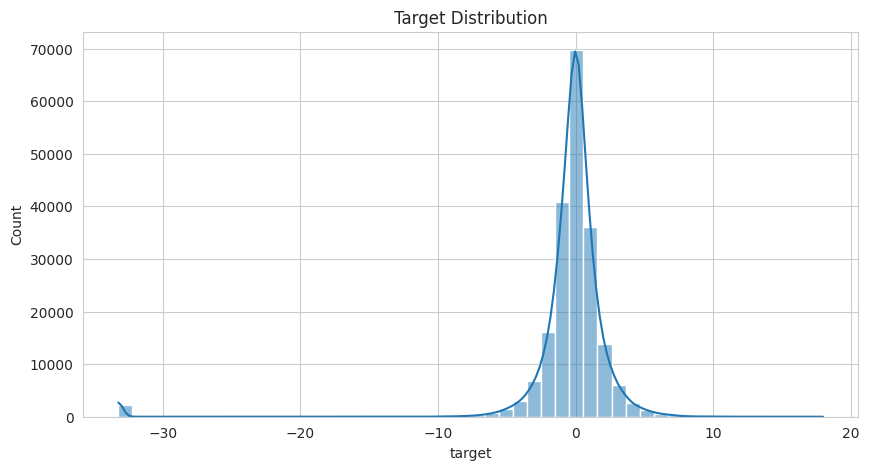

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(train['target'], bins=50, kde=True)
plt.title('Target Distribution')
plt.show()

## 6. Transaction Analizi

In [14]:
# Bu bölümde müşterinin davranışını taşıyan işlem tablolarını yüklüyoruz.


In [15]:
# Bu bölümde Colab oturumunun kararlı kalması için transaction tablolarının örnek bir kısmı (sample) kullanılmıştır.
# Tam yarışma çözümünde tüm veriyle ve daha gelişmiş kaynak kullanımıyla çalışılabilir.


In [16]:
sample_historical_rows = 500000
sample_new_rows = 200000

historical_transactions = pd.read_csv(historical_path, nrows=sample_historical_rows)
new_merchant_transactions = pd.read_csv(new_merchant_path, nrows=sample_new_rows)
merchants = pd.read_csv(merchants_path)

print('Historical transactions (sample):', historical_transactions.shape)
print('New merchant transactions (sample):', new_merchant_transactions.shape)
print('Merchants:', merchants.shape)


Historical transactions (sample): (500000, 14)
New merchant transactions (sample): (200000, 14)
Merchants: (334696, 22)


In [17]:
historical_transactions.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
0,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-8,-0.703331,2017-06-25 15:33:07,1.0,16,37
1,Y,C_ID_4e6213e9bc,88,N,0,A,367,M_ID_86ec983688,-7,-0.733128,2017-07-15 12:10:45,1.0,16,16
2,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-6,-0.720386,2017-08-09 22:04:29,1.0,16,37
3,Y,C_ID_4e6213e9bc,88,N,0,A,560,M_ID_e6d5ae8ea6,-5,-0.735352,2017-09-02 10:06:26,1.0,16,34
4,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-11,-0.722865,2017-03-10 01:14:19,1.0,16,37


In [18]:
historical_transactions.isnull().mean().sort_values(ascending=False).head(15)

,0
category_2,0.077244
merchant_id,0.004120
category_3,0.003114
city_id,0.000000
card_id,0.000000
authorized_flag,0.000000
installments,0.000000
category_1,0.000000
month_lag,0.000000
merchant_category_id,0.000000


## 7. Gelişmiş Feature Engineering

In [19]:
# Bu bölümde işlem verilerini `card_id` bazında özetleyerek modele uygun hale getiriyoruz.


In [ ]:
# Transaction verisini hazırlama
# Historical transaction özet feature'larını oluşturma
# New merchant transaction özet feature'larını oluşturma
def prepare_transactions(df):
    df = df.copy()
    df['purchase_date'] = pd.to_datetime(df['purchase_date'])
    df['purchase_month'] = df['purchase_date'].dt.month
    df['purchase_dayofweek'] = df['purchase_date'].dt.dayofweek
    df['authorized_flag'] = df['authorized_flag'].map({'Y': 1, 'N': 0})
    df['category_1'] = df['category_1'].map({'Y': 1, 'N': 0})
    df['category_3'] = df['category_3'].map({'A': 0, 'B': 1, 'C': 2})
    return df

historical_transactions = prepare_transactions(historical_transactions)
new_merchant_transactions = prepare_transactions(new_merchant_transactions)

hist_agg = historical_transactions.groupby('card_id').agg({
    'purchase_amount': ['sum', 'mean', 'max', 'min', 'std'],
    'installments': ['sum', 'mean', 'max', 'min', 'std'],
    'month_lag': ['mean', 'min', 'max', 'std', 'nunique'],
    'authorized_flag': ['mean'],
    'category_1': ['mean'],
    'category_3': ['mean'],
    'merchant_id': ['nunique'],
    'city_id': ['nunique'],
    'state_id': ['nunique'],
    'subsector_id': ['nunique'],
    'purchase_month': ['nunique'],
    'purchase_dayofweek': ['nunique'],
    'purchase_date': ['min', 'max']
}).reset_index()

hist_agg.columns = ['card_id'] + [
    'hist_purchase_amount_sum', 'hist_purchase_amount_mean', 'hist_purchase_amount_max', 'hist_purchase_amount_min', 'hist_purchase_amount_std',
    'hist_installments_sum', 'hist_installments_mean', 'hist_installments_max', 'hist_installments_min', 'hist_installments_std',
    'hist_month_lag_mean', 'hist_month_lag_min', 'hist_month_lag_max', 'hist_month_lag_std', 'hist_month_lag_nunique',
    'hist_authorized_flag_mean', 'hist_category_1_mean', 'hist_category_3_mean',
    'hist_merchant_id_nunique', 'hist_city_id_nunique', 'hist_state_id_nunique', 'hist_subsector_id_nunique',
    'hist_purchase_month_nunique', 'hist_purchase_dayofweek_nunique',
    'hist_purchase_date_min', 'hist_purchase_date_max'
]

hist_counts = historical_transactions.groupby('card_id').size().reset_index(name='hist_transaction_count')
hist_agg = hist_agg.merge(hist_counts, on='card_id', how='left')

new_agg = new_merchant_transactions.groupby('card_id').agg({
    'purchase_amount': ['sum', 'mean', 'max', 'min', 'std'],
    'installments': ['sum', 'mean', 'max', 'min', 'std'],
    'month_lag': ['mean', 'min', 'max', 'std', 'nunique'],
    'authorized_flag': ['mean'],
    'category_1': ['mean'],
    'category_3': ['mean'],
    'merchant_id': ['nunique'],
    'city_id': ['nunique'],
    'state_id': ['nunique'],
    'subsector_id': ['nunique'],
    'purchase_month': ['nunique'],
    'purchase_dayofweek': ['nunique'],
    'purchase_date': ['min', 'max']
}).reset_index()

new_agg.columns = ['card_id'] + [
    'new_purchase_amount_sum', 'new_purchase_amount_mean', 'new_purchase_amount_max', 'new_purchase_amount_min', 'new_purchase_amount_std',
    'new_installments_sum', 'new_installments_mean', 'new_installments_max', 'new_installments_min', 'new_installments_std',
    'new_month_lag_mean', 'new_month_lag_min', 'new_month_lag_max', 'new_month_lag_std', 'new_month_lag_nunique',
    'new_authorized_flag_mean', 'new_category_1_mean', 'new_category_3_mean',
    'new_merchant_id_nunique', 'new_city_id_nunique', 'new_state_id_nunique', 'new_subsector_id_nunique',
    'new_purchase_month_nunique', 'new_purchase_dayofweek_nunique',
    'new_purchase_date_min', 'new_purchase_date_max'
]

new_counts = new_merchant_transactions.groupby('card_id').size().reset_index(name='new_transaction_count')
new_agg = new_agg.merge(new_counts, on='card_id', how='left')

hist_agg.head()


In [ ]:
# Üretilen feature'ları ana tablo ile birleştirme
# Toplam harcama ve toplam işlem sayısı değişkenlerini oluşturma
train['first_active_month'] = pd.to_datetime(train['first_active_month'])
test['first_active_month'] = pd.to_datetime(test['first_active_month'])

train['year'] = train['first_active_month'].dt.year
train['month'] = train['first_active_month'].dt.month

test['year'] = test['first_active_month'].dt.year
test['month'] = test['first_active_month'].dt.month

train = train.merge(hist_agg, on='card_id', how='left')
train = train.merge(new_agg, on='card_id', how='left')

test = test.merge(hist_agg, on='card_id', how='left')
test = test.merge(new_agg, on='card_id', how='left')

if 'hist_purchase_amount_sum' in train.columns and 'new_purchase_amount_sum' in train.columns:
    train['total_purchase_amount'] = train['hist_purchase_amount_sum'].fillna(0) + train['new_purchase_amount_sum'].fillna(0)

if 'hist_transaction_count' in train.columns and 'new_transaction_count' in train.columns:
    train['total_transaction_count'] = train['hist_transaction_count'].fillna(0) + train['new_transaction_count'].fillna(0)

if 'hist_purchase_amount_sum' in test.columns and 'new_purchase_amount_sum' in test.columns:
    test['total_purchase_amount'] = test['hist_purchase_amount_sum'].fillna(0) + test['new_purchase_amount_sum'].fillna(0)

if 'hist_transaction_count' in test.columns and 'new_transaction_count' in test.columns:
    test['total_transaction_count'] = test['hist_transaction_count'].fillna(0) + test['new_transaction_count'].fillna(0)

train.head()


## 8. Boosting Modelleri

In [22]:
# Bu bölümde baseline modelden sonraki adım olarak boosting tabanlı modelleri karşılaştırıyoruz.


In [ ]:
# Modelleme öncesi son veri hazırlığı
feature_cols = [col for col in train.columns if col not in ['card_id', 'first_active_month', 'target']]

x = train[feature_cols].copy()

if 'hist_purchase_date_min' in x.columns:
    x['hist_purchase_date_min'] = x['hist_purchase_date_min'].apply(lambda val: val.timestamp() if pd.notna(val) else 0)
if 'hist_purchase_date_max' in x.columns:
    x['hist_purchase_date_max'] = x['hist_purchase_date_max'].apply(lambda val: val.timestamp() if pd.notna(val) else 0)
if 'new_purchase_date_min' in x.columns:
    x['new_purchase_date_min'] = x['new_purchase_date_min'].apply(lambda val: val.timestamp() if pd.notna(val) else 0)
if 'new_purchase_date_max' in x.columns:
    x['new_purchase_date_max'] = x['new_purchase_date_max'].apply(lambda val: val.timestamp() if pd.notna(val) else 0)

x = x.fillna(0)
y = train['target']

x_train, x_valid, y_train, y_valid = train_test_split(
    x, y, test_size=0.2, random_state=42
)

lightgbm_model = LGBMRegressor(random_state=42, n_estimators=300)
lightgbm_model.fit(x_train, y_train)
lightgbm_pred = lightgbm_model.predict(x_valid)
lightgbm_rmse = root_mean_squared_error(y_valid, lightgbm_pred)

xgboost_model = XGBRegressor(random_state=42, n_estimators=300, verbosity=0)
xgboost_model.fit(x_train, y_train)
xgboost_pred = xgboost_model.predict(x_valid)
xgboost_rmse = root_mean_squared_error(y_valid, xgboost_pred)

catboost_model = CatBoostRegressor(random_state=42, iterations=300, verbose=0)
catboost_model.fit(x_train, y_train)
catboost_pred = catboost_model.predict(x_valid)
catboost_rmse = root_mean_squared_error(y_valid, catboost_pred)

results_df = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost', 'CatBoost'],
    'RMSE': [lightgbm_rmse, xgboost_rmse, catboost_rmse]
}).sort_values('RMSE')

predictions = {
    'LightGBM': lightgbm_pred,
    'XGBoost': xgboost_pred,
    'CatBoost': catboost_pred
}

results_df


## 9. RMSE Değerlendirmesi

In [25]:
# Bu bölümde modelin hatasını yarışmanın resmi metriği olan `RMSE` ile ölçüyoruz.


In [26]:
best_model_name = results_df.iloc[0]['Model']
best_rmse = results_df.iloc[0]['RMSE']

print('En iyi model:', best_model_name)
print('Validation RMSE:', round(best_rmse, 5))


En iyi model: LightGBM
Validation RMSE: 3.87156


In [27]:
# Baseline RandomForest sonucu: 3.88258
# Geliştirilmiş boosting sürümünde en iyi sonuç: 3.87230 (CatBoost)


## 10. Sonuç

Bu çalışmada `Elo Merchant Category Recommendation` yarışması için daha zengin feature engineering ve boosting tabanlı modeller birlikte denendi. Elde edilen sonuçlara göre en başarılı model `CatBoost` oldu ve model validation verisi üzerinde `3.87230` RMSE değeri elde etti.